In [1]:
import cv2 as cv
import cv2
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from matplotlib.ticker import MultipleLocator

In [2]:
Cam1_ins = np.load("Matrix_calibration\Cam1_Fisher_Intrinsic.npz") #左摄像头
mtx1, dist1 = (Cam1_ins['mtx'], Cam1_ins['dist'])
Cam2_ins = np.load("Matrix_calibration\Cam2_Fisher_Intrinsic.npz") #右摄像头
mtx2, dist2 = (Cam2_ins['mtx'], Cam2_ins['dist'])
# Cam3_ins = np.load("Matrix_calibrate\Cam3_Fisher_Intrinsic.npz") #辅助摄像头
# mtx3, dist3 = (Cam3_ins['mtx'], Cam3_ins['dist'])
#标定cam1和cam2外参时,采集数据 cam1和cam2颠倒，cam1数据为右摄像头，cam2数据为左摄像头
R1_2, T1_2 = np.load("Matrix_calibration\Cam1_to_Cam2_Fisher_Extrinsic.npz")['R'], np.load("Matrix_calibration\Cam1_to_Cam2_Fisher_Extrinsic.npz")['T']
R2_1, T2_1 = np.load("Matrix_calibration\Cam2_to_Cam1_Fisher_Extrinsic.npz")['R'], np.load("Matrix_calibration\Cam2_to_Cam1_Fisher_Extrinsic.npz")['T']
#标定cam1和cam3外参, 数据正常，cam1数据
# R1_3, T1_3 = np.load("Matrix_calibrate\Cam1_to_Cam3_Fisher_Extrinsic.npz")['R'], np.load("Matrix_calibrate\Cam1_to_Cam3_Fisher_Extrinsic.npz")['T']
# R3_1, T3_1 = np.load("Matrix_calibrate\Cam3_to_Cam1_Fisher_Extrinsic.npz")['R'], np.load("Matrix_calibrate\Cam3_to_Cam1_Fisher_Extrinsic.npz")['T']

In [3]:
from scipy import linalg
class Stereo_Screen_Location():
    def __init__(self, mtx1, mtx2, dist1, dist2, R1_2, R2_1, T1_2, T2_1, H1=0, H2=0):
        self.mtx1 = mtx1
        self.mtx2 = mtx2
        self.dist1 = dist1
        self.dist2 = dist2
        self.R1_2 = R1_2 #Cam1到Cam2的旋转矩阵 [x2, y2, z2, 1] = [[R1_2, T1_2], [0,1] @ [x1, y1, z1, 1]
        self.R2_1 = R2_1 #Cam2到Cam1的旋转矩阵 [x1, y1, z1, 1] = [[R2_1, T2_1], [0,1] @ [x2, y2, z2, 1]
        self.T1_2 = T1_2
        self.T2_1 = T2_1
        self.H1 = H1 #Cam1相机坐标系到平面坐标系的仿射矩阵
        self.H2 = H2 #Cam2相机坐标系到平面坐标系的仿射矩阵
    def undistort_points(self, uvs, mtx, dist):
        uvs = np.array(uvs).reshape((-1, 1, 2)).astype(np.float32)
        undistort_uvs = cv2.fisheye.undistortPoints(uvs, K=mtx, D=dist, P=mtx)
        return undistort_uvs.reshape(-1, 2)
    # 通过直接线性变换方法将二维图像点反投影到三维空间
    def DLT(self, P1, P2, point1, point2):
        A = [point1[1]*P1[2,:] - P1[1,:],
             P1[0,:] - point1[0]*P1[2,:],
             point2[1]*P2[2,:] - P2[1,:],
             P2[0,:] - point2[0]*P2[2,:]
            ]
        A = np.array(A).reshape((4,4))
        B = A.transpose() @ A
        U, s, Vh = linalg.svd(B, full_matrices=False)
        return Vh[3,0:3]/Vh[3,3]
    def get_cam2_xyz(self, uvs1, uvs2):
        RT1 = np.concatenate([np.eye(3), [[0],[0],[0]]], axis=-1)
        P1 = self.mtx1 @ RT1

        RT2 = np.concatenate([self.R1_2, self.T1_2], axis=-1)
        P2 = self.mtx2 @ RT2

        p3ds = []
        for uv1, uv2 in zip(uvs1, uvs2):
            _p3d = self.DLT(P1, P2, uv1, uv2)
            p3ds.append(_p3d)
        p3ds = np.array(p3ds)
        return p3ds
    def get_cam1_xyz(self, uvs1, uvs2):
        RT2 = np.concatenate([np.eye(3), [[0],[0],[0]]], axis=-1)
        P2 = self.mtx2 @ RT2

        RT1 = np.concatenate([self.R2_1, self.T2_1], axis=-1)
        P1 = self.mtx1 @ RT1

        p3ds = []
        for uv1, uv2 in zip(uvs1, uvs2):
            _p3d = self.DLT(P1, P2, uv1, uv2)
            p3ds.append(_p3d)
        p3ds = np.array(p3ds)
        return p3ds
    # 计算屏幕坐标
    def cal_screen_xy(self, baseline, dis1, dis2):
        p = (baseline + dis1 + dis2) / 2
        area = np.sqrt(p * (p-baseline) * (p-dis1) * (p-dis2))

        y = area * 2 / baseline
        sin_theta = y / dis1
        cos_theta = np.sqrt(1 - sin_theta ** 2)
        x = dis1 * cos_theta
        return np.vstack((x,y)).T
    # 将二维图像点反投影到相机坐标系下的三维空间
    def pxl2cam(self, uvs1, uvs2):
        undistort_uvs1 = self.undistort_points(uvs1, self.mtx1, self.dist1)
        undistort_uvs2 = self.undistort_points(uvs2, self.mtx2, self.dist2)
        cam1_3d = self.get_cam1_xyz(undistort_uvs1, undistort_uvs2)
        cam2_3d = self.get_cam2_xyz(undistort_uvs1, undistort_uvs2)
        return cam1_3d, cam2_3d
    # 将相机1坐标系下的三维点转换到屏幕坐标系
    def pxl2camleft2screen(self, uvs1, uvs2):
        cam1_3d, cam2_3d  = self.pxl2cam(uvs1, uvs2)
        cam1_3d_point = np.append(cam1_3d,1)
        pred_sreen_point = self.H1 @ cam1_3d_point
        return pred_sreen_point
    def pxl2camright2screen(self, uvs1, uvs2):
        cam1_3d, cam2_3d  = self.pxl2cam(uvs1, uvs2)
        cam2_3d_point = np.append(cam2_3d,1)
        pred_sreen_point = self.H2 @ cam2_3d_point
        return pred_sreen_point
    # def pxl2screen(self,uvs1, uvs2):
    #     undistort_uvs1 = self.undistort_points(uvs1, self.mtx1, self.dist1)
    #     undistort_uvs2 = self.undistort_points(uvs2, self.mtx2, self.dist2)
    #     cam1_3d = self.get_cam1_xyz(undistort_uvs1, undistort_uvs2)
    #     cam2_3d = self.get_cam2_xyz(undistort_uvs1, undistort_uvs2)
    #     baseline = np.linalg.norm(self.T1_2)
    #     dis1 = np.linalg.norm(cam1_3d)
    #     dis2 = np.linalg.norm(cam2_3d)
    #     screen_xy = self.cal_screen_xy(baseline, dis1, dis2)
    #     return screen_xy

### 方法2：直接标定Cam1相机坐标系和Screen坐标系的仿射变换，不依赖辅助相机，只适用于单个机器进行标

方法2：直接标定Cam1相机坐标系和Screen坐标系的仿射变换

比较笨的方法, 首先人为找到屏幕中每个角点（用一个极细笔尖点击角点），人为找到两个图像的像素坐标，然后通过cam1和cam2内外参和三角测量得到cam1的相机坐标系坐标(3D)，最后根据角点的物理位置(角点在屏幕中的物理距离)，相机坐标系和物理坐标进行配对PnP解算仿射矩阵

In [13]:


stereo_loc = Stereo_Screen_Location(mtx1, mtx2, dist1, dist2, R1_2, R2_1, T1_2, T2_1)
cam1_3d_points = []
cam2_3d_points = []

screen_points1 = np.array([[0,0,0],[340,0,0],[0,180,0],[340,180,0]],dtype=np.float32)
print(screen_points1)

cam1_point_uvs = [[307,305],[94,218],[556,242],[250,222]]
cam2_point_uvs = [[483,245],[300,311],[342,239],[19,232]]

for i in range(len(cam1_point_uvs)):
    cam1_3d, cam2_3d  = stereo_loc.pxl2cam(uvs1=cam1_point_uvs[i], uvs2=cam2_point_uvs[i])
    cam1_3d_points.append(cam1_3d[0])
    cam2_3d_points.append(cam2_3d[0])
cam1_3d_points = np.array(cam1_3d_points)
cam2_3d_points = np.array(cam2_3d_points)

ret, H1, affine_matrix = cv.estimateAffine3D(cam1_3d_points, screen_points1)
ret, H2, affine_matrix = cv.estimateAffine3D(cam2_3d_points, screen_points1)

np.savez("Cam1_to_Screen_Extrinsic.npz", H = H1)
np.savez("Cam2_to_Screen_Extrinsic.npz", H = H2)
    

[[  0.   0.   0.]
 [340.   0.   0.]
 [  0. 180.   0.]
 [340. 180.   0.]]


In [23]:

print("H1:", H1)
print("H2:", H2)

1
H1: [[ -0.5887234   -0.5681088   -0.79300354 356.32236716]
 [ -0.66992594  -2.6132968    0.51495986   0.86712702]
 [  0.           0.           0.           0.        ]]
H2: [[ -0.66468105  -0.08941985   0.7326957  -14.68345157]
 [  0.82611439  -2.72789349   0.78381944  -0.66132121]
 [  0.           0.           0.           0.        ]]


评估误差

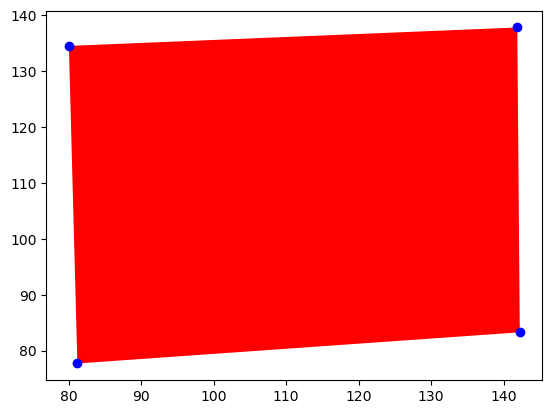

pxl2camlet2screen: [[ 81.17136232  77.72207409   0.        ]
 [142.24766328  83.29577246   0.        ]
 [141.90304526 137.81495776   0.        ]
 [ 80.00302814 134.51934918   0.        ]]


In [20]:
H1 = np.load("Cam1_to_Screen_Extrinsic.npz")['H']
H2 = np.load("Cam2_to_Screen_Extrinsic.npz")['H']
stereo_loc = Stereo_Screen_Location(mtx1, mtx2, dist1, dist2, R1_2, R2_1, T1_2, T2_1,H1,H2)
uvs1_tl, uvs2_tl = [[323,235]], [[388,243]]
uvs1_tr, uvs2_tr = [[262,227]], [[366,240]]
uvs1_dl, uvs2_dl = [[387, 241]], [[339, 239]]
uvs1_dr, uvs2_dr = [[324, 233]], [[310, 238]]
screen_tl = stereo_loc.pxl2camleft2screen(uvs1_tl, uvs2_tl)
screen_tr = stereo_loc.pxl2camleft2screen(uvs1_tr, uvs2_tr)
screen_dl = stereo_loc.pxl2camleft2screen(uvs1_dl, uvs2_dl)
screen_dr = stereo_loc.pxl2camleft2screen(uvs1_dr, uvs2_dr)
screen_pts = np.array([screen_tl, screen_tr, screen_dr, screen_dl]).reshape(-1,3) # 每个点都是(x, y)
x = screen_pts[:, 0]  #构造横坐标数据
y = screen_pts[:, 1]  #构造纵坐标数据
plt.plot(x, y, 'bo')
plt.fill(x, y, 'r')
plt.show()  # 可以看出，世界坐标系中的box基本是个矩形
print('pxl2camlet2screen:',screen_pts)

# screen_tl = stereo_loc.pxl2camright2screen(uvs1_tl, uvs2_tl)
# screen_tr = stereo_loc.pxl2camright2screen(uvs1_tr, uvs2_tr)
# screen_dl = stereo_loc.pxl2camright2screen(uvs1_dl, uvs2_dl)
# screen_dr = stereo_loc.pxl2camright2screen(uvs1_dr, uvs2_dr)
# screen_pts = np.array([screen_tl, screen_tr, screen_dr, screen_dl]).reshape(-1,3) # 每个点都是(x, y)
# x = screen_pts[:, 0]  #构造横坐标数据
# y = screen_pts[:, 1]  #构造纵坐标数据
# plt.plot(x, y, 'bo')
# plt.fill(x, y, 'r')
# plt.show()  # 可以看出，世界坐标系中的box基本是个矩形
# print('pxl2camright2screen:',screen_pts)


In [21]:
errors = []
screen_points2 = np.array([[80,80,0],[140,80,0],[140,140,0],[80,140,0]],dtype=np.float32)
for i in range(len(screen_points2)):
    pred_sreen_point = screen_pts[i]
    gt_screen_point = screen_points2[i]
    error = pred_sreen_point - gt_screen_point
    
    errors.append(error)
errors = np.array(errors)   
print(np.mean(abs(errors),axis=0))
print(np.std(abs(errors),axis=0))

[1.33127475 3.30984786 0.        ]
[0.85972386 1.32689809 0.        ]
